Kütüphaneleri ve Temiz Veriyi Yükleme

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Veriyi okurken AYIRICI (sep) ve ONDALIK (decimal) parametrelerini ekliyoruz
dosya_yolu = "../data/processed/dogo_temiz_veri_final.csv"
df = pd.read_csv(dosya_yolu, sep=';', decimal=',')

print(f"Veri yeni formatıyla başarıyla yüklendi! Boyut: {df.shape}")
print("Sütunlar:", df.columns.tolist()[:5], "...") # İlk 5 sütunu görelim

Veri yeni formatıyla başarıyla yüklendi! Boyut: (3174, 31)
Sütunlar: ['siparis_no', 'uye_grup_kodu', 'uye_grubu', 'uye_ws_kodu', 'il_teslimat'] ...


Kargo Firmalarının Ortalama Teslimat Süreleri

C:\Users\gizem\AppData\Local\Temp\ipykernel_6548\1459619099.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafik1 = sns.barplot(


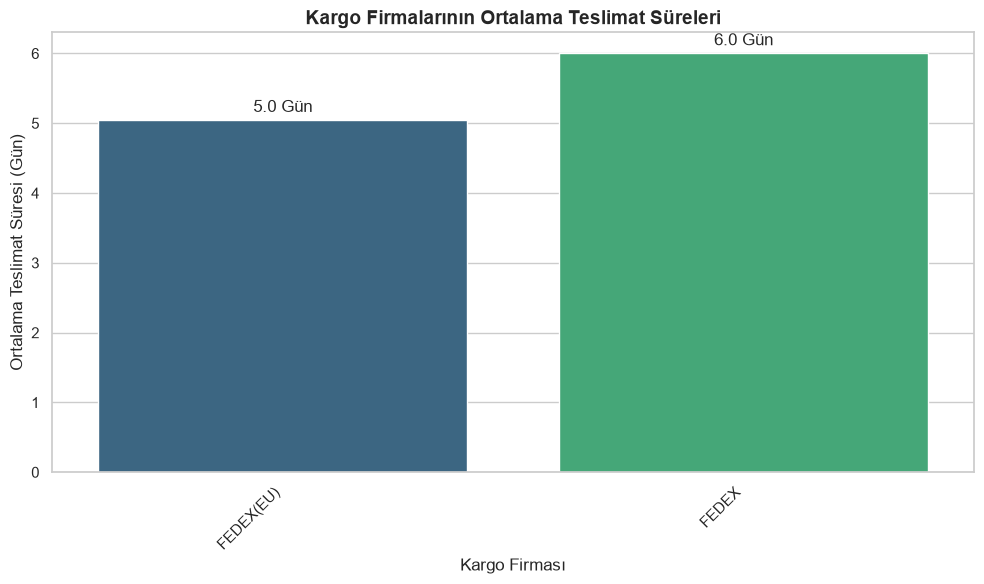

In [15]:
# 1. Kargo firması sütununa sızan "Ödeme Yöntemlerini" filtreliyoruz
# İçinde bu kelimeler geçen satırları kargo firması saymayacağız
sahte_kargolar = ['KREDI', 'HAVALE', 'KAPIDA', 'BANKA', 'PAY', 'CREDIT', 'EFT']
# str.contains ile bu kelimeleri içermeyenleri (~ işareti ile) alıyoruz
df_gercek_kargo = df[~df['kargo_firmasi'].astype(str).str.upper().str.contains('|'.join(sahte_kargolar), na=False)]

# Kargo firmalarına göre ortalama teslimat süresini hesaplıyoruz
kargo_hiz_tablosu = df_gercek_kargo.groupby('kargo_firmasi')['teslimat_suresi_gun'].mean().sort_values().reset_index()

plt.figure(figsize=(10, 6))
grafik1 = sns.barplot(
    x='kargo_firmasi', 
    y='teslimat_suresi_gun', 
    data=kargo_hiz_tablosu, 
    palette='viridis'
)

# Barların üzerine gün değerlerini yazdırma
for p in grafik1.patches:
    grafik1.annotate(format(p.get_height(), '.1f') + ' Gün', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Kargo Firmalarının Ortalama Teslimat Süreleri', fontsize=14, fontweight='bold')
plt.xlabel('Kargo Firması', fontsize=12)
plt.ylabel('Ortalama Teslimat Süresi (Gün)', fontsize=12)
# Yazıların birbirine girmemesi için 45 derece yatırıp hizalamayı sağa çekiyoruz
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Geciken Kargo İadeyi Tetikliyor mu?

C:\Users\gizem\AppData\Local\Temp\ipykernel_6548\499419675.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


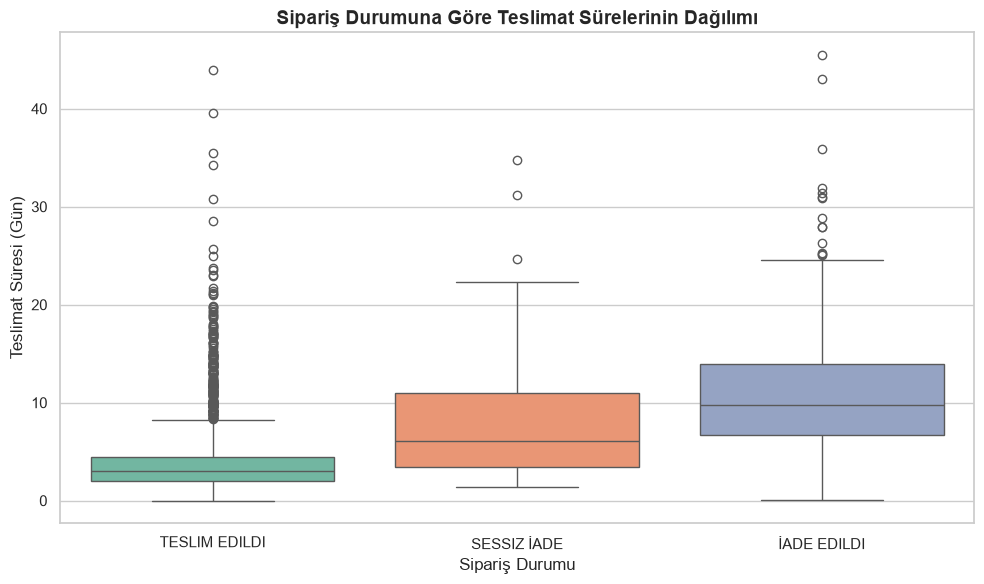

Sipariş Durumuna Göre Ortalama Teslimat Süreleri (Gün):
siparis_durumu
SESSIZ İADE       8.2
TESLIM EDILDI     4.1
İADE EDILDI      11.2
Name: teslimat_suresi_gun, dtype: float64


In [16]:
# 2. Büyük/Küçük harf hatasına düşmemek için dinamik filtreleme yapıyoruz
# "İçinde iptal kelimesi geçmeyen tüm durumları (Teslim, İade vb.) al" diyoruz
hedef_durumlar = [durum for durum in df['siparis_durumu'].dropna().unique() if 'PTAL' not in str(durum).upper()]
df_kargo_analizi = df[df['siparis_durumu'].isin(hedef_durumlar)]

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='siparis_durumu', 
    y='teslimat_suresi_gun', 
    data=df_kargo_analizi, 
    palette='Set2'
)

plt.title('Sipariş Durumuna Göre Teslimat Sürelerinin Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Sipariş Durumu', fontsize=12)
plt.ylabel('Teslimat Süresi (Gün)', fontsize=12)
plt.tight_layout()
plt.show()

# İstatistikleri görelim
print("Sipariş Durumuna Göre Ortalama Teslimat Süreleri (Gün):")
print(df_kargo_analizi.groupby('siparis_durumu')['teslimat_suresi_gun'].mean().round(1))

Platformlara Göre İade ve İptal Oranları

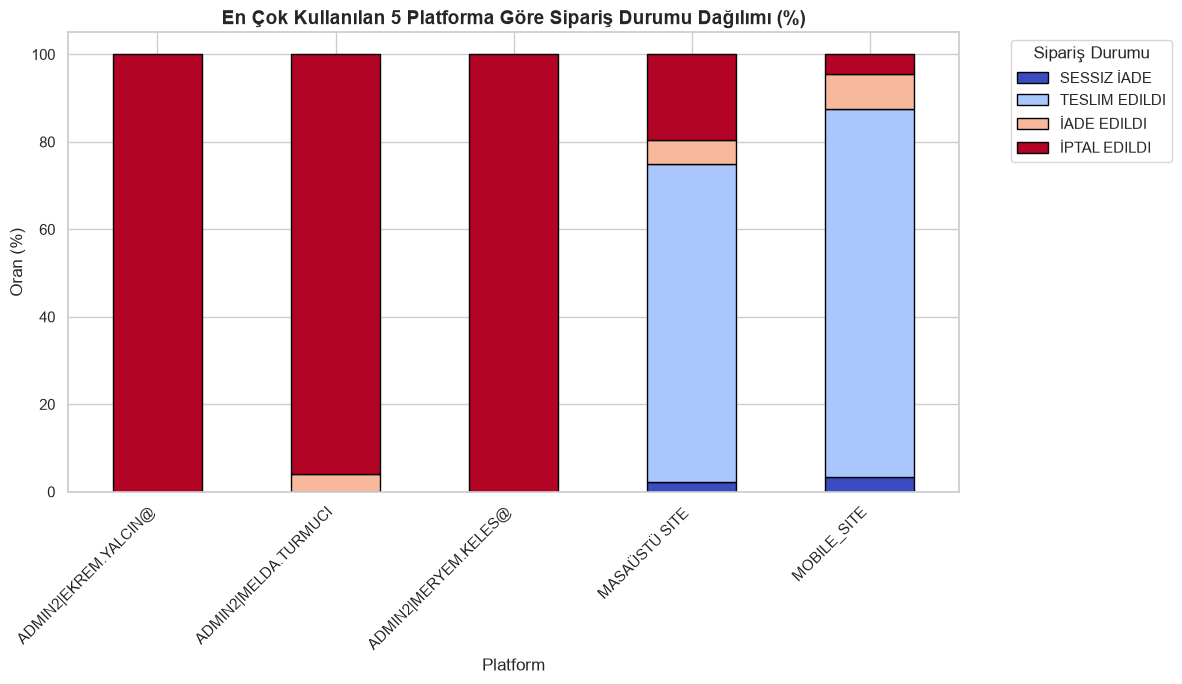

Platformlara Göre Toplam Sipariş Adetleri:
platform
MOBILE_SITE             2500
MASAÜSTÜ SITE            640
ADMIN2|MELDA.TURMUCI      24
ADMIN2|MERYEM.KELES@       7
ADMIN2|EKREM.YALCIN@       2
ADMIN2|BEGUM.CELEBI@       1
Name: count, dtype: int64


In [17]:
# 3. Grafik kalabalığını önlemek için sadece en çok satış yapılan İLK 5 PLATFORMU alıyoruz
top_5_platform = df['platform'].value_counts().head(5).index
df_top_platform = df[df['platform'].isin(top_5_platform)]

# Platform ve Sipariş Durumu kırılımında oranları hesaplıyoruz
platform_durum = pd.crosstab(df_top_platform['platform'], df_top_platform['siparis_durumu'], normalize='index') * 100

platform_durum.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='coolwarm', edgecolor='black')

plt.title('En Çok Kullanılan 5 Platforma Göre Sipariş Durumu Dağılımı (%)', fontsize=14, fontweight='bold')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Oran (%)', fontsize=12)
plt.legend(title='Sipariş Durumu', bbox_to_anchor=(1.05, 1), loc='upper left')
# Yazıları hizalıyoruz
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Platformlara Göre Toplam Sipariş Adetleri:")
print(df['platform'].value_counts())

Hangi günlerde verilen siparişler daha çok iadeye veya iptale kurban gidiyor?

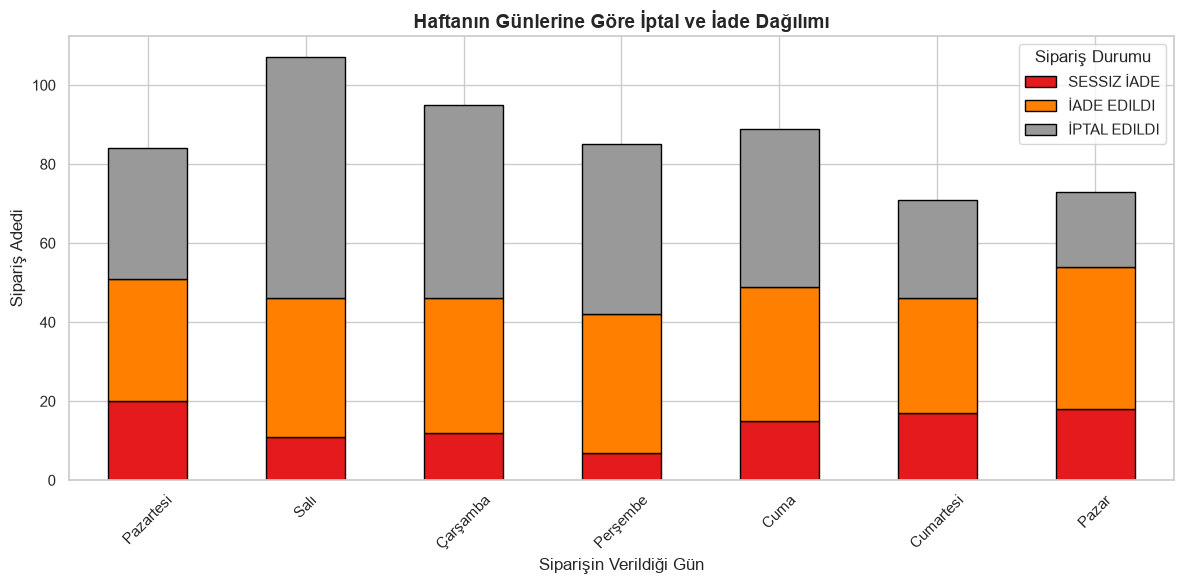

Günlere ve Durumlara Göre Detaylı Kırılım:
siparis_durumu  SESSIZ İADE  İADE EDILDI  İPTAL EDILDI
siparis_gunu                                          
Pazartesi                20           31            33
Salı                     11           35            61
Çarşamba                 12           34            49
Perşembe                  7           35            43
Cuma                     15           34            40
Cumartesi                17           29            25
Pazar                    18           36            19


In [21]:
# 1. Büyük/küçük harf veya Türkçe karakter sorununa takılmamak için dinamik filtreleme yapıyoruz
tum_durumlar = df['siparis_durumu'].dropna().unique()

# İçinde "İPTAL, IPTAL, İADE, IADE, SESSİZ, SESSIZ" kelimelerinden herhangi biri geçen durumları otomatik bul
sorunlu_durumlar = [durum for durum in tum_durumlar if any(kelime in str(durum).upper() for kelime in ['İPTAL', 'IPTAL', 'İADE', 'IADE', 'SESSİZ', 'SESSIZ'])]

# Sadece bu sorunlu durumları içeren satırları filtreliyoruz
df_sorunlu = df[df['siparis_durumu'].isin(sorunlu_durumlar)]

# 2. Günleri haftanın akışına göre sıralıyoruz (Pandas günleri İngilizce üretir)
gun_siralamasi_ing = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
gunluk_analiz = pd.crosstab(df_sorunlu['siparis_gunu'], df_sorunlu['siparis_durumu'])

# Günleri doğru sıraya sokup, eksik gün varsa 0 ile dolduruyoruz
gunluk_analiz = gunluk_analiz.reindex(gun_siralamasi_ing).fillna(0)

# 3. Grafikte şık durması için İngilizce günleri Türkçeye çeviriyoruz
gun_isimleri_tr = {
    'Monday': 'Pazartesi', 'Tuesday': 'Salı', 'Wednesday': 'Çarşamba', 
    'Thursday': 'Perşembe', 'Friday': 'Cuma', 'Saturday': 'Cumartesi', 'Sunday': 'Pazar'
}
gunluk_analiz = gunluk_analiz.rename(index=gun_isimleri_tr)

# 4. Grafiği Çizdiriyoruz
gunluk_analiz.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set1', edgecolor='black')

plt.title('Haftanın Günlerine Göre İptal ve İade Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Siparişin Verildiği Gün', fontsize=12)
plt.ylabel('Sipariş Adedi', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Sipariş Durumu')
plt.tight_layout()
plt.show()
print("Günlere ve Durumlara Göre Detaylı Kırılım:")
# Tablonun içindeki tüm detayları tam sayı olarak yazdırıyoruz
print(gunluk_analiz.astype(int))

Kampanya ve Sepet Büyüklüğünün İadeye Etkisi

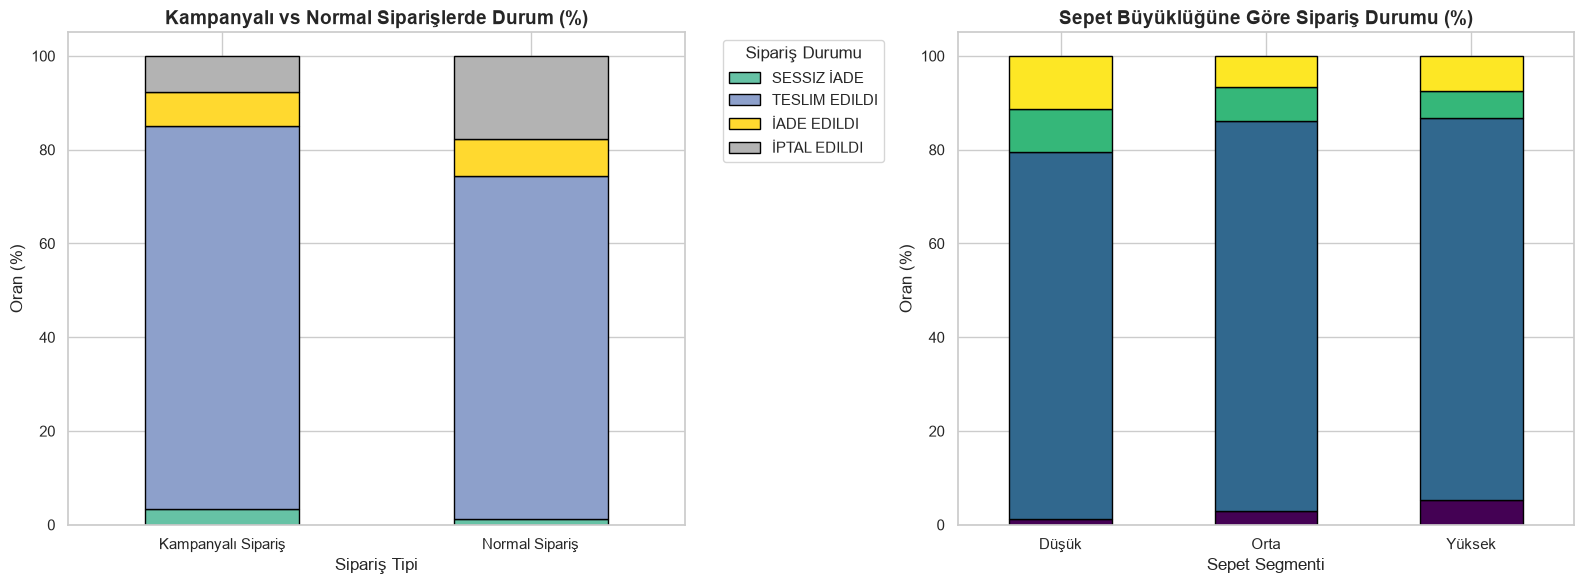

--- KAMPANYA ETKİSİ (%) ---
siparis_durumu      SESSIZ İADE  TESLIM EDILDI  İADE EDILDI  İPTAL EDILDI
kampanya_etiket                                                          
Kampanyalı Sipariş          3.3           81.7          7.3           7.7
Normal Sipariş              1.1           73.2          8.0          17.6

--- SEPET SEGMENTİ ETKİSİ (%) ---
siparis_durumu  SESSIZ İADE  TESLIM EDILDI  İADE EDILDI  İPTAL EDILDI
sepet_segmenti                                                       
Düşük                   1.2           78.3          9.1          11.4
Orta                    2.9           83.3          7.2           6.6
Yüksek                  5.4           81.3          5.7           7.6


In [22]:
# --- 1. KAMPANYA ETKİSİ GRAFİĞİ ---
# 1 ve 0'ları grafikte şık durması için isimlendiriyoruz
df['kampanya_etiket'] = df['kampanyali_mi'].map({1: 'Kampanyalı Sipariş', 0: 'Normal Sipariş'})

# Normalize='index' diyerek sayıları değil, her grubun kendi içindeki YÜZDESİNİ (%) alıyoruz
kampanya_analiz = pd.crosstab(df['kampanya_etiket'], df['siparis_durumu'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Yan yana 2 grafik çizeceğiz

# Kampanya Grafiği (Soldaki)
kampanya_analiz.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Kampanyalı vs Normal Siparişlerde Durum (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sipariş Tipi', fontsize=12)
axes[0].set_ylabel('Oran (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sipariş Durumu', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- 2. SEPET SEGMENTİ ETKİSİ GRAFİĞİ ---
# Sepet segmentlerini Düşük, Orta, Yüksek sırasına diziyoruz
sepet_analiz = pd.crosstab(df['sepet_segmenti'], df['siparis_durumu'], normalize='index') * 100
sepet_analiz = sepet_analiz.reindex(['Düşük', 'Orta', 'Yüksek'])

# Sepet Segmenti Grafiği (Sağdaki)
sepet_analiz.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis', edgecolor='black')
axes[1].set_title('Sepet Büyüklüğüne Göre Sipariş Durumu (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sepet Segmenti', fontsize=12)
axes[1].set_ylabel('Oran (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
# İkinci grafikte de legend çıkacak ama zaten aynı renkler olduğu için onu gizleyelim, kalabalık yapmasın
axes[1].get_legend().remove() 

plt.tight_layout()
plt.show()

# İncelememiz için yüzdelik verileri konsola da yazdıralım
print("--- KAMPANYA ETKİSİ (%) ---")
print(kampanya_analiz.round(1))
print("\n--- SEPET SEGMENTİ ETKİSİ (%) ---")
print(sepet_analiz.round(1))

**Çıkarımsal İstatistik (Inferential Statistics)**

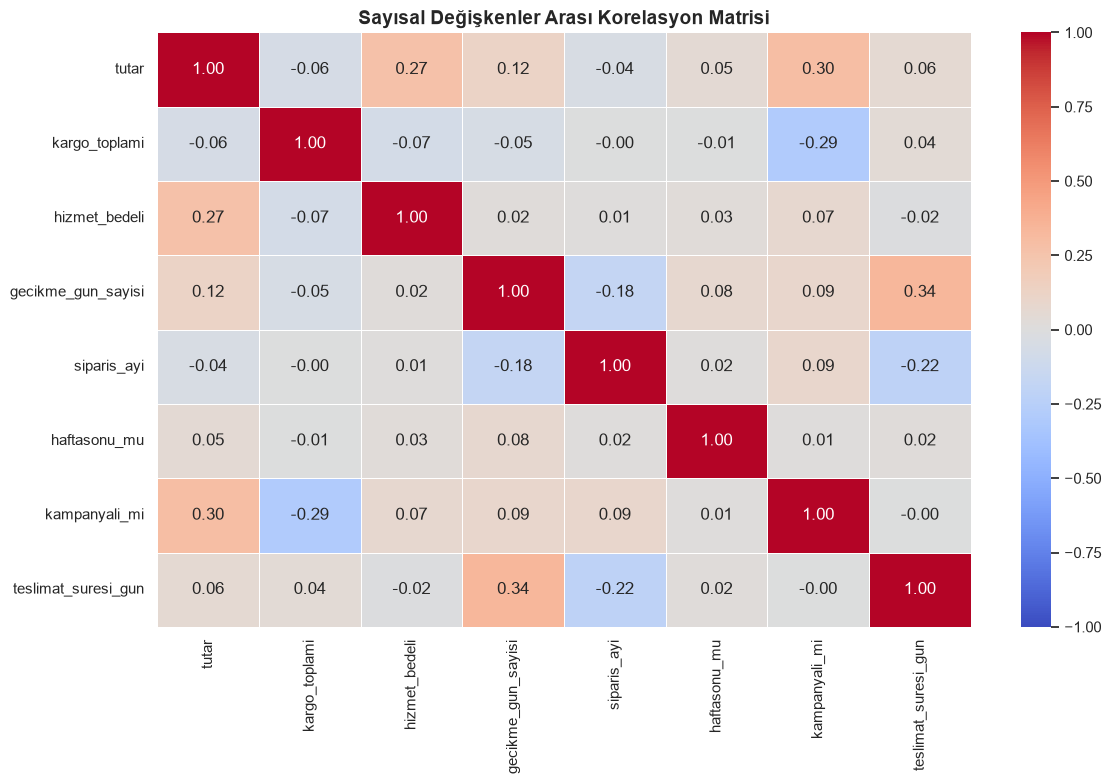


🔬 --- İSTATİSTİKSEL T-TESTİ SONUÇLARI --- 🔬
T-İstatistiği Skoru: -14.65
P-Değeri (p-value): 0.0000000000
--------------------------------------------------
SONUÇ: p-value < 0.05 olduğu için aradaki fark İSTATİSTİKSEL OLARAK ANLAMLIDIR.
BİLİMSEL KANIT: Teslim edilenler ile İade edilenlerin kargo süreleri arasındaki uçurum tesadüf değildir. Geciken kargo, matematiksel olarak iadeyi doğrudan tetiklemektedir!


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# --------------------------------------------------
# 1. KORELASYON MATRİSİ (ISI HARİTASI)
# --------------------------------------------------
# Sadece sayısal olan sütunları seçiyoruz ki matematiksel çarpıştırma yapabilelim
sayisal_df = df.select_dtypes(include=['float64', 'int64', 'int32'])

plt.figure(figsize=(12, 8))
# annot=True ile kutuların içine oranları yazdırıyoruz
sns.heatmap(sayisal_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2. BAĞIMSIZ ÖRNEKLEM T-TESTİ (Gecikme -> İade Kanıtı)
# --------------------------------------------------
# "Teslim Edilenler 4 günde, İade Edilenler 11 günde gidiyor" tezini test ediyoruz.
teslim_edilenler = df[df['siparis_durumu'] == 'TESLIM EDILDI']['teslimat_suresi_gun'].dropna()
iade_edilenler = df[df['siparis_durumu'] == 'İADE EDILDI']['teslimat_suresi_gun'].dropna()

# İki bağımsız grup arasındaki farkın istatistiksel anlamını ölçüyoruz
t_stat, p_value = stats.ttest_ind(teslim_edilenler, iade_edilenler, equal_var=False)

print("\n🔬 --- İSTATİSTİKSEL T-TESTİ SONUÇLARI --- 🔬")
print(f"T-İstatistiği Skoru: {t_stat:.2f}")
print(f"P-Değeri (p-value): {p_value:.10f}")
print("-" * 50)

if p_value < 0.05:
    print("SONUÇ: p-value < 0.05 olduğu için aradaki fark İSTATİSTİKSEL OLARAK ANLAMLIDIR.")
    print("BİLİMSEL KANIT: Teslim edilenler ile İade edilenlerin kargo süreleri arasındaki uçurum tesadüf değildir. Geciken kargo, matematiksel olarak iadeyi doğrudan tetiklemektedir!")
else:
    print("SONUÇ: p-value >= 0.05 olduğu için aradaki fark istatistiksel olarak anlamsızdır (tesadüfidir).")

**Ki-Kare Testi**

In [25]:
from scipy.stats import chi2_contingency

# 1. Çapraz Tabloyu (Contingency Table) Oluşturuyoruz
# Hangi platformda hangi durumdan kaç adet var, saf sayısal matrisini çıkarıyoruz.
# Sadece anlamlı veriyi test etmek için platform isimleri "ADMIN" ile başlamayanları alalım.
df_gercek_platformlar = df[~df['platform'].str.contains('ADMIN', na=False)]
crosstab_platform = pd.crosstab(df_gercek_platformlar['platform'], df_gercek_platformlar['siparis_durumu'])

print("📊 Çapraz Tablo (Gözlemlenen Değerler):")
print(crosstab_platform)
print("\n" + "-"*50 + "\n")

# 2. Ki-Kare Testini Uyguluyoruz
chi2, p_val, dof, expected = chi2_contingency(crosstab_platform)

print("🔬 --- Kİ-KARE TESTİ SONUÇLARI (PLATFORM vs SİPARİŞ DURUMU) --- 🔬")
print(f"Ki-Kare İstatistiği: {chi2:.2f}")
print(f"Serbestlik Derecesi (DOF): {dof}")
print(f"P-Değeri (p-value): {p_val:.10f}")
print("-" * 50)

# 3. Sonucu Yorumluyoruz
if p_val < 0.05:
    print("SONUÇ: p-value < 0.05 olduğu için aradaki ilişki İSTATİSTİKSEL OLARAK ANLAMLIDIR.")
    print("BİLİMSEL KANIT: Müşterinin kullandığı platform (Mobil vs. Masaüstü) ile siparişin iade/iptal edilmesi arasında güçlü bir matematiksel bağ vardır. Platform bağımsız bir faktör değildir!")
else:
    print("SONUÇ: p-value >= 0.05 olduğu için aradaki farklar istatistiksel olarak anlamsızdır (tesadüfidir).")

📊 Çapraz Tablo (Gözlemlenen Değerler):
siparis_durumu  SESSIZ İADE  TESLIM EDILDI  İADE EDILDI  İPTAL EDILDI
platform                                                             
MASAÜSTÜ SITE            15            465           35           125
MOBILE_SITE              85           2105          198           112

--------------------------------------------------

🔬 --- Kİ-KARE TESTİ SONUÇLARI (PLATFORM vs SİPARİŞ DURUMU) --- 🔬
Ki-Kare İstatistiği: 167.15
Serbestlik Derecesi (DOF): 3
P-Değeri (p-value): 0.0000000000
--------------------------------------------------
SONUÇ: p-value < 0.05 olduğu için aradaki ilişki İSTATİSTİKSEL OLARAK ANLAMLIDIR.
BİLİMSEL KANIT: Müşterinin kullandığı platform (Mobil vs. Masaüstü) ile siparişin iade/iptal edilmesi arasında güçlü bir matematiksel bağ vardır. Platform bağımsız bir faktör değildir!


En Çok Sipariş Gelen İlk 10 Kaynak:
kaynak
FACEBOOK            771
IG                  460
PERSONACLICK         28
ZUBIZU               25
SMS                  17
FB                   16
VODAFONE              5
SEGMENTIFY            3
TH                    1
CHATGPT.COM           1
IGSHOPPING            1
CORPORATEBENEFIT      1
ENHENCER              1
TRUSTPILOT            1
Name: count, dtype: int64
--------------------------------------------------
Kaynaklara Göre Sipariş Durumu Dağılımı (%):
siparis_durumu  SESSIZ İADE  TESLIM EDILDI  İADE EDILDI  İPTAL EDILDI
kaynak                                                               
FACEBOOK                2.5           84.4          8.6           4.5
IG                      3.7           85.4          7.2           3.7
PERSONACLICK            7.1           78.6         14.3           0.0
SMS                     0.0           88.2         11.8           0.0
ZUBIZU                  8.0           68.0         16.0           8.0


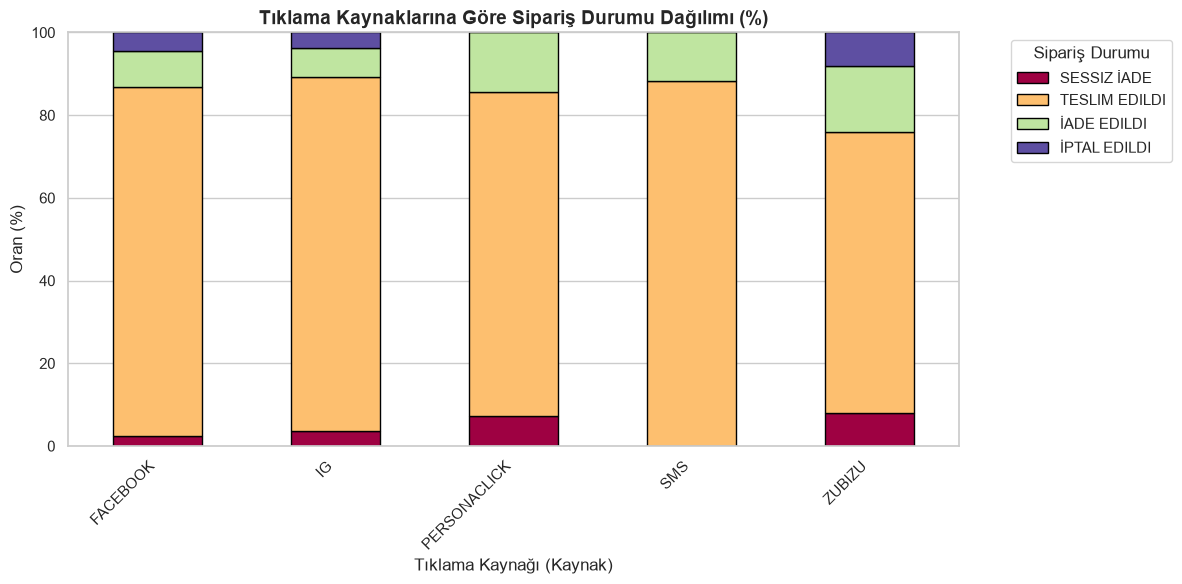

In [30]:
# 1. En çok trafik getiren ilk 10 kaynağı görelim
print("En Çok Sipariş Gelen İlk 10 Kaynak:")
print(df['kaynak'].value_counts().head(20))
print("-" * 50)

# 2. Veride kalabalık yapmaması için en popüler İLK 5 KAYNAĞI seçiyoruz
top_5_kaynak = df['kaynak'].value_counts().head(5).index
df_top_kaynak = df[df['kaynak'].isin(top_5_kaynak)]

# 3. Kaynak ve Sipariş Durumu kırılımında Yüzdelik (%) tablo oluşturuyoruz
kaynak_durum_orani = pd.crosstab(df_top_kaynak['kaynak'], df_top_kaynak['siparis_durumu'], normalize='index') * 100

print("Kaynaklara Göre Sipariş Durumu Dağılımı (%):")
print(kaynak_durum_orani.round(1))

# 4. Bunu çok şık bir ısı haritası veya bar grafiğiyle görselleştirelim
kaynak_durum_orani.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Spectral', edgecolor='black')
plt.title('Tıklama Kaynaklarına Göre Sipariş Durumu Dağılımı (%)', fontsize=14, fontweight='bold')
plt.xlabel('Tıklama Kaynağı (Kaynak)', fontsize=12)
plt.ylabel('Oran (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sipariş Durumu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()